# Análisis exploratorio de datos multivariable


## Objetivo

- Identificar correlaciones entre datos que puedan servir como referencia para la formulación de hipótesis sobre relaciones causa efecto.


## Técnicas

- Covarianza - mide la relación lineal entre dos variables (si incrementan o decrementan juntas). Una covarianza positiva indica que las variables se mueven en la misma dirección y un covarianza negativa que las variables cambian en direcciones opuestas. Sin embargo, **no permite valorar la 'intensidad' de la relación.**

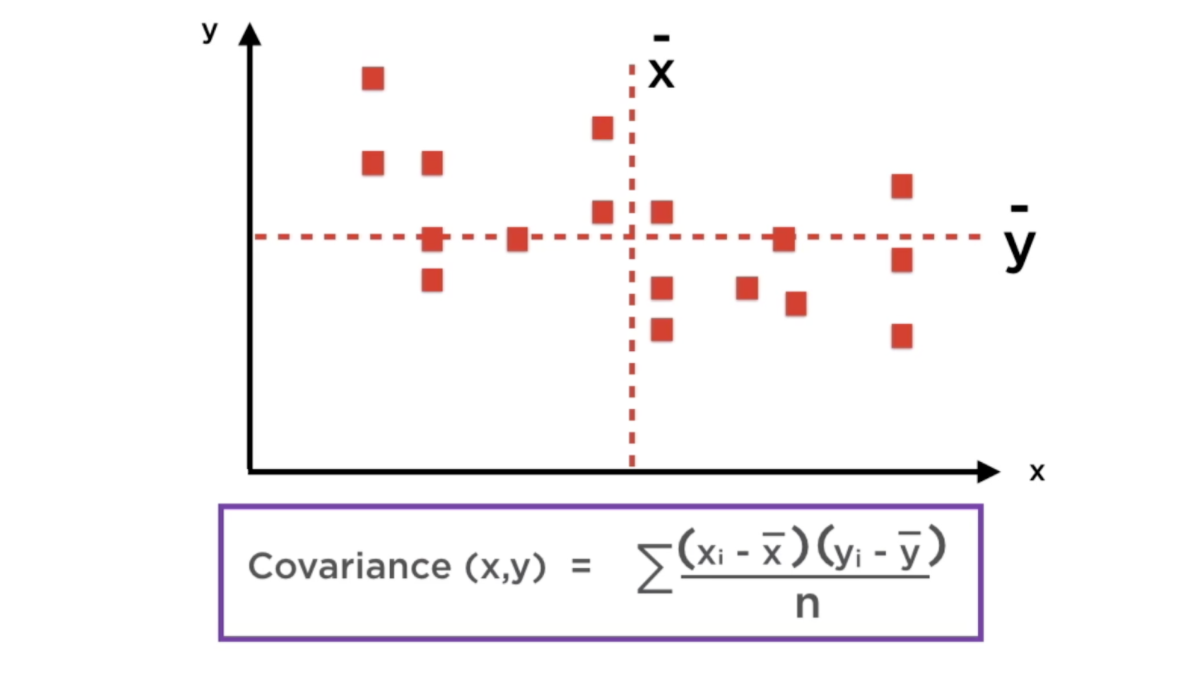

- Coeficiente de correlación - igual que la covarianza mide la dirección pero tambien la intensidad de la relación. Es importante recordar que  __[correlación no implica causalidad](https://es.wikipedia.org/wiki/Cum_hoc_ergo_propter_hoc)__

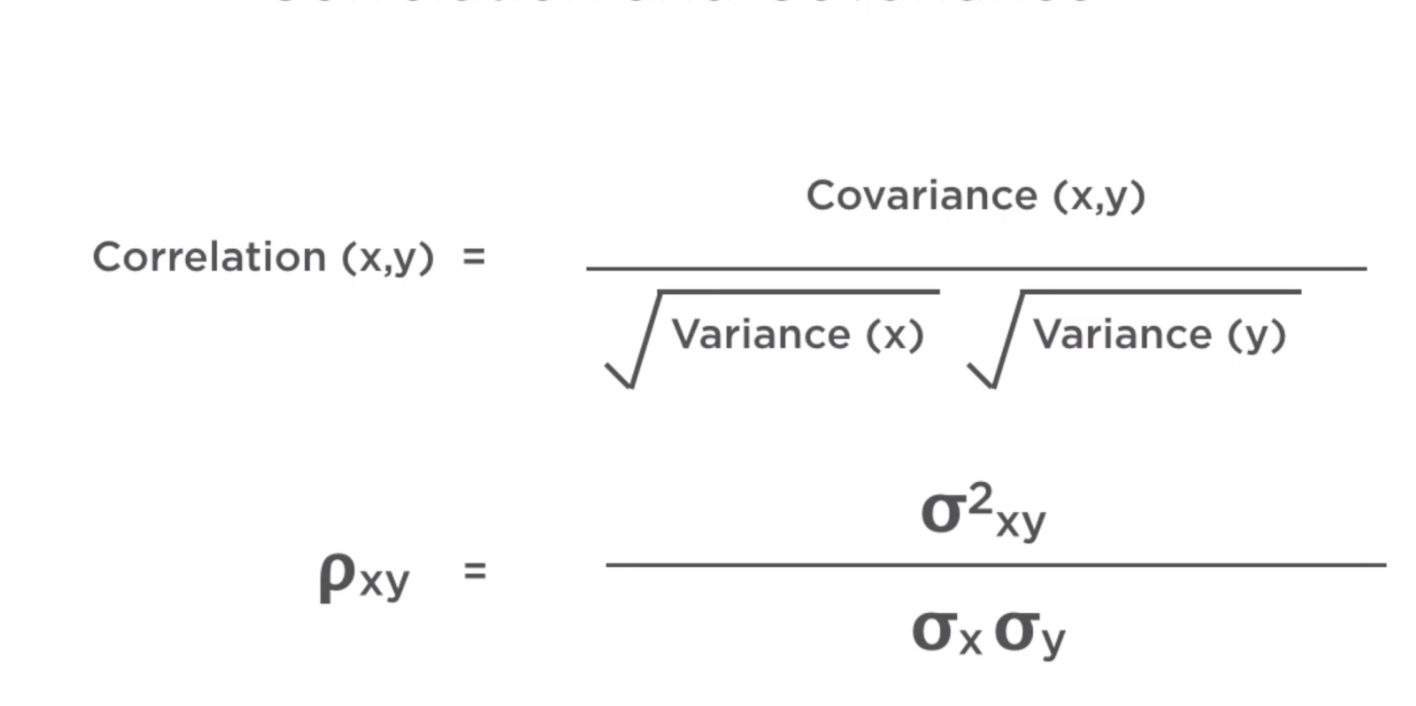

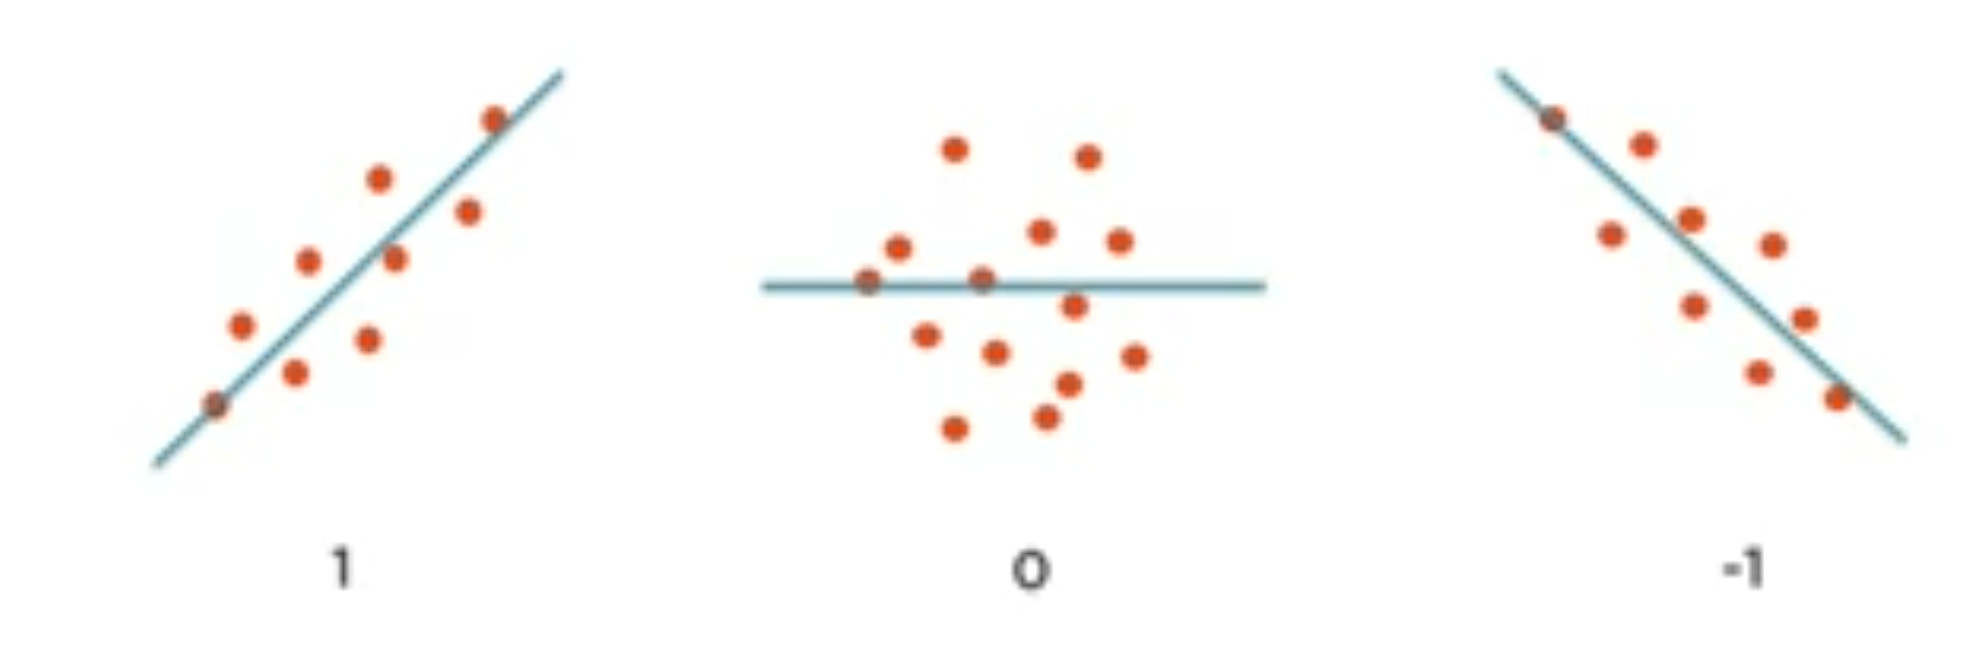

Para dos variables independientes el coefiente de correlación muy probablemente será igual a cero; sin embargo, un coeficiente de correlación igual a cero no necesarimente implica que las variables sean independientes. Por esta razón, **el cálculo del coeficiente de correlación debe ser complementado con la exploración visual de los datos.**

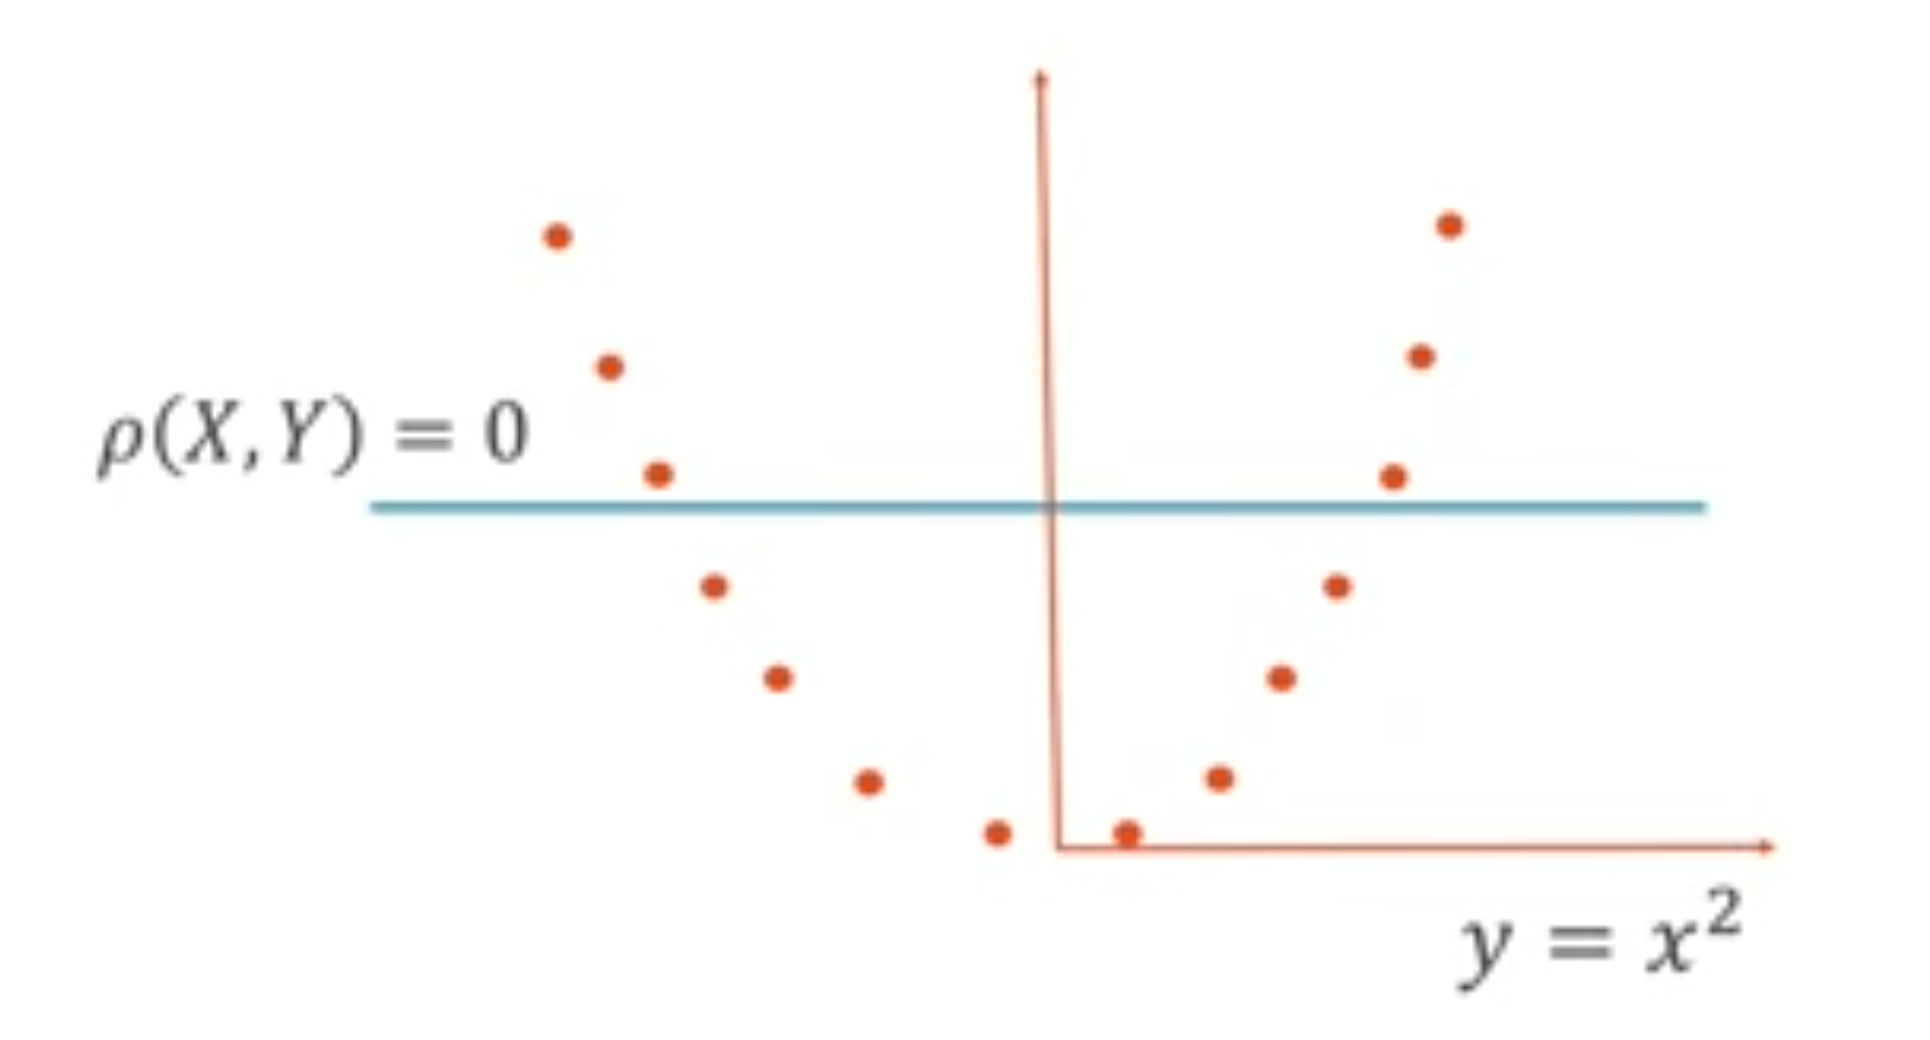

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carga de datos
__[Fuente de datos](https://github.com/mwaskom/seaborn-data)__

In [52]:
import polars as pl

In [53]:
type(sns.load_dataset('tips'))

pandas.core.frame.DataFrame

In [54]:
tips_pl = pl.from_pandas(sns.load_dataset('tips'))
tips_pl.tail()

total_bill,tip,sex,smoker,day,time,size
f64,f64,cat,cat,cat,cat,i64
29.03,5.92,"""Male""","""No""","""Sat""","""Dinner""",3
27.18,2.0,"""Female""","""Yes""","""Sat""","""Dinner""",2
22.67,2.0,"""Male""","""Yes""","""Sat""","""Dinner""",2
17.82,1.75,"""Male""","""No""","""Sat""","""Dinner""",2
18.78,3.0,"""Female""","""No""","""Thur""","""Dinner""",2


In [55]:
tips = sns.load_dataset('tips')

## Covarianza y correlación

In [56]:
import polars.selectors as cs

In [57]:
tips_pl.select(cs.numeric())

total_bill,tip,size
f64,f64,i64
16.99,1.01,2
10.34,1.66,3
21.01,3.5,3
23.68,3.31,2
24.59,3.61,4
…,…,…
29.03,5.92,3
27.18,2.0,2
22.67,2.0,2


In [58]:
# Polars no tiene un método `.cov()` que devuelva una matriz de covarianzas
# completa directamente como Pandas
matriz_cov = np.cov(tips_pl.select(cs.numeric()).to_numpy(), rowvar=False)

print(matriz_cov)

[[79.25293861  8.32350163  5.06598344]
 [ 8.32350163  1.91445464  0.64390643]
 [ 5.06598344  0.64390643  0.90459084]]


In [59]:
tips.cov(numeric_only=True)

,total_bill,tip,size
total_bill,79.252939,8.323502,5.065983
tip,8.323502,1.914455,0.643906
size,5.065983,0.643906,0.904591


In [60]:
# Matriz de correlación, forma rápida para análisis visual
# Si necesitas visualizarla como una matriz tradicional o un heatmap
# conversión rápida a Pandas después de la selección
tips_pl.select(cs.numeric()).to_pandas().corr()

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


In [61]:
tips.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


## Visualización



In [62]:
chart =  (
    tips_pl.plot.point(
        x="total_bill",
        y="tip",
    )
    .properties(width=500, title="Scatter plot : Tip by Total bill" )
    .configure_scale(zero=False)
    .configure_axisX(tickMinStep=1)
    .configure_point(opacity=0.3)
)
chart.encoding.x.title = "Total bill"
chart.encoding.y.title = "Tipe"
chart

alt.Chart(...)

<Axes: title={'center': 'scatter plot : Tip by Total bill'}, xlabel='total_bill', ylabel='tip'>

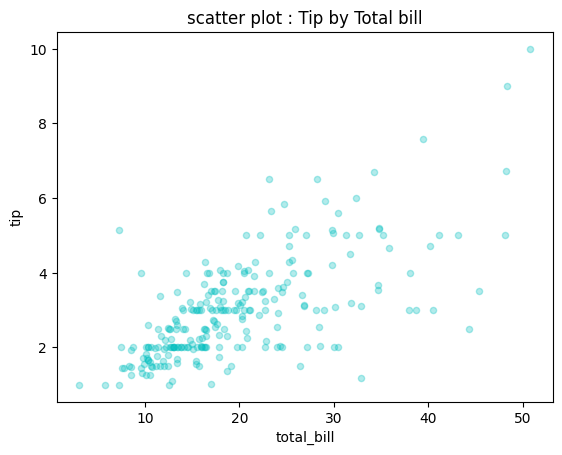

In [63]:
tips.plot.scatter(x='total_bill', y='tip', color='c', title='scatter plot : Tip by Total bill', alpha=0.3)

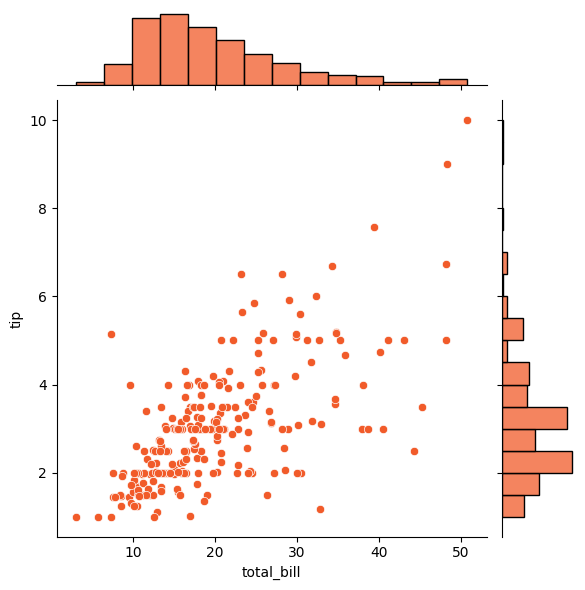

In [64]:
sns.jointplot(x='total_bill', y='tip', data=tips_pl, color='#F15B2A')

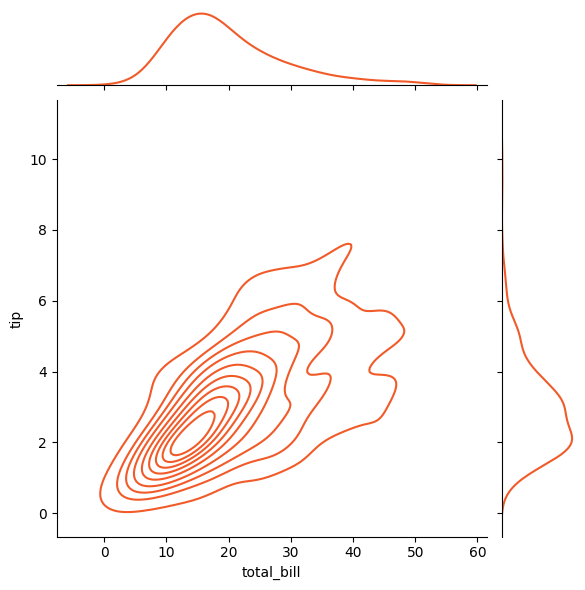

In [65]:
sns.jointplot(x='total_bill', y='tip', data=tips_pl, color='#F15B2A', kind='kde')

<Axes: >

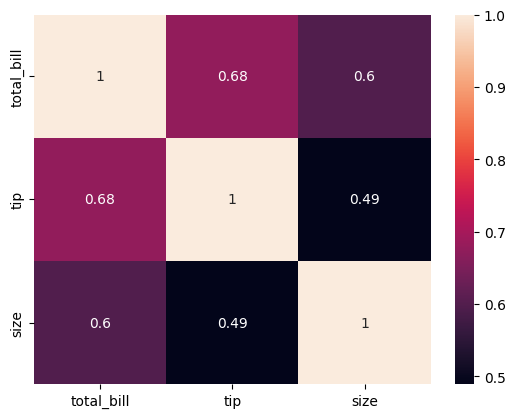

In [66]:
sns.heatmap(tips.corr(numeric_only=True), annot = True)

## Variables cualitativas
### Crosstabs (tablas de contingencia)

In [67]:
tips_pl.head()

total_bill,tip,sex,smoker,day,time,size
f64,f64,cat,cat,cat,cat,i64
16.99,1.01,"""Female""","""No""","""Sun""","""Dinner""",2
10.34,1.66,"""Male""","""No""","""Sun""","""Dinner""",3
21.01,3.5,"""Male""","""No""","""Sun""","""Dinner""",3
23.68,3.31,"""Male""","""No""","""Sun""","""Dinner""",2
24.59,3.61,"""Female""","""No""","""Sun""","""Dinner""",4


In [68]:
#Conteos de la combinacion de variables nominales
pd.crosstab(tips["smoker"], tips["sex"])

sex,Male,Female
smoker,,
Yes,60,33
No,97,54


### Equivalente a crosstab en Polars

En Polars, utilizamos `.pivot()` para crear tablas de contingencia. Para contar frecuencias, usamos `index` para las filas, `on` para las columnas y `aggregate_function="len"`.

In [69]:
# Replicando pd.crosstab(tips["smoker"], tips["sex"]) de Pandas
crosstab_pl = tips_pl.pivot(
    index="smoker",
    on="sex",
    values="tip", # Se requiere una columna de valor, pero 'len' solo contará registros
    aggregate_function="len"
)

display(crosstab_pl)

smoker,Female,Male
cat,u32,u32
"""No""",54,97
"""Yes""",33,60


In [70]:
crosstab_pl.plot.bar()

alt.Chart(...)

### Visualización del Crosstab en Polars

Podemos usar el objeto resultante del pivot para generar un gráfico de barras apiladas o agrupadas.

In [71]:
# Para graficar múltiples columnas, transformamos a formato largo (long-form)
# Esto evita errores de esquema en Altair al recibir listas en 'y'
(
    crosstab_pl.unpivot(index="smoker", on=["Female", "Male"], variable_name="sex", value_name="count")
    .plot.bar(
        x="smoker",
        y="count",
        color="sex"
    )
    .properties(
        title="Frecuencia de fumadores por sexo (Polars)",
        width=400
    )
)

alt.Chart(...)

### Pivot (tablas de contingencia)

Extensión del crosstab que permite analizar dos variables categoricas y una numérica

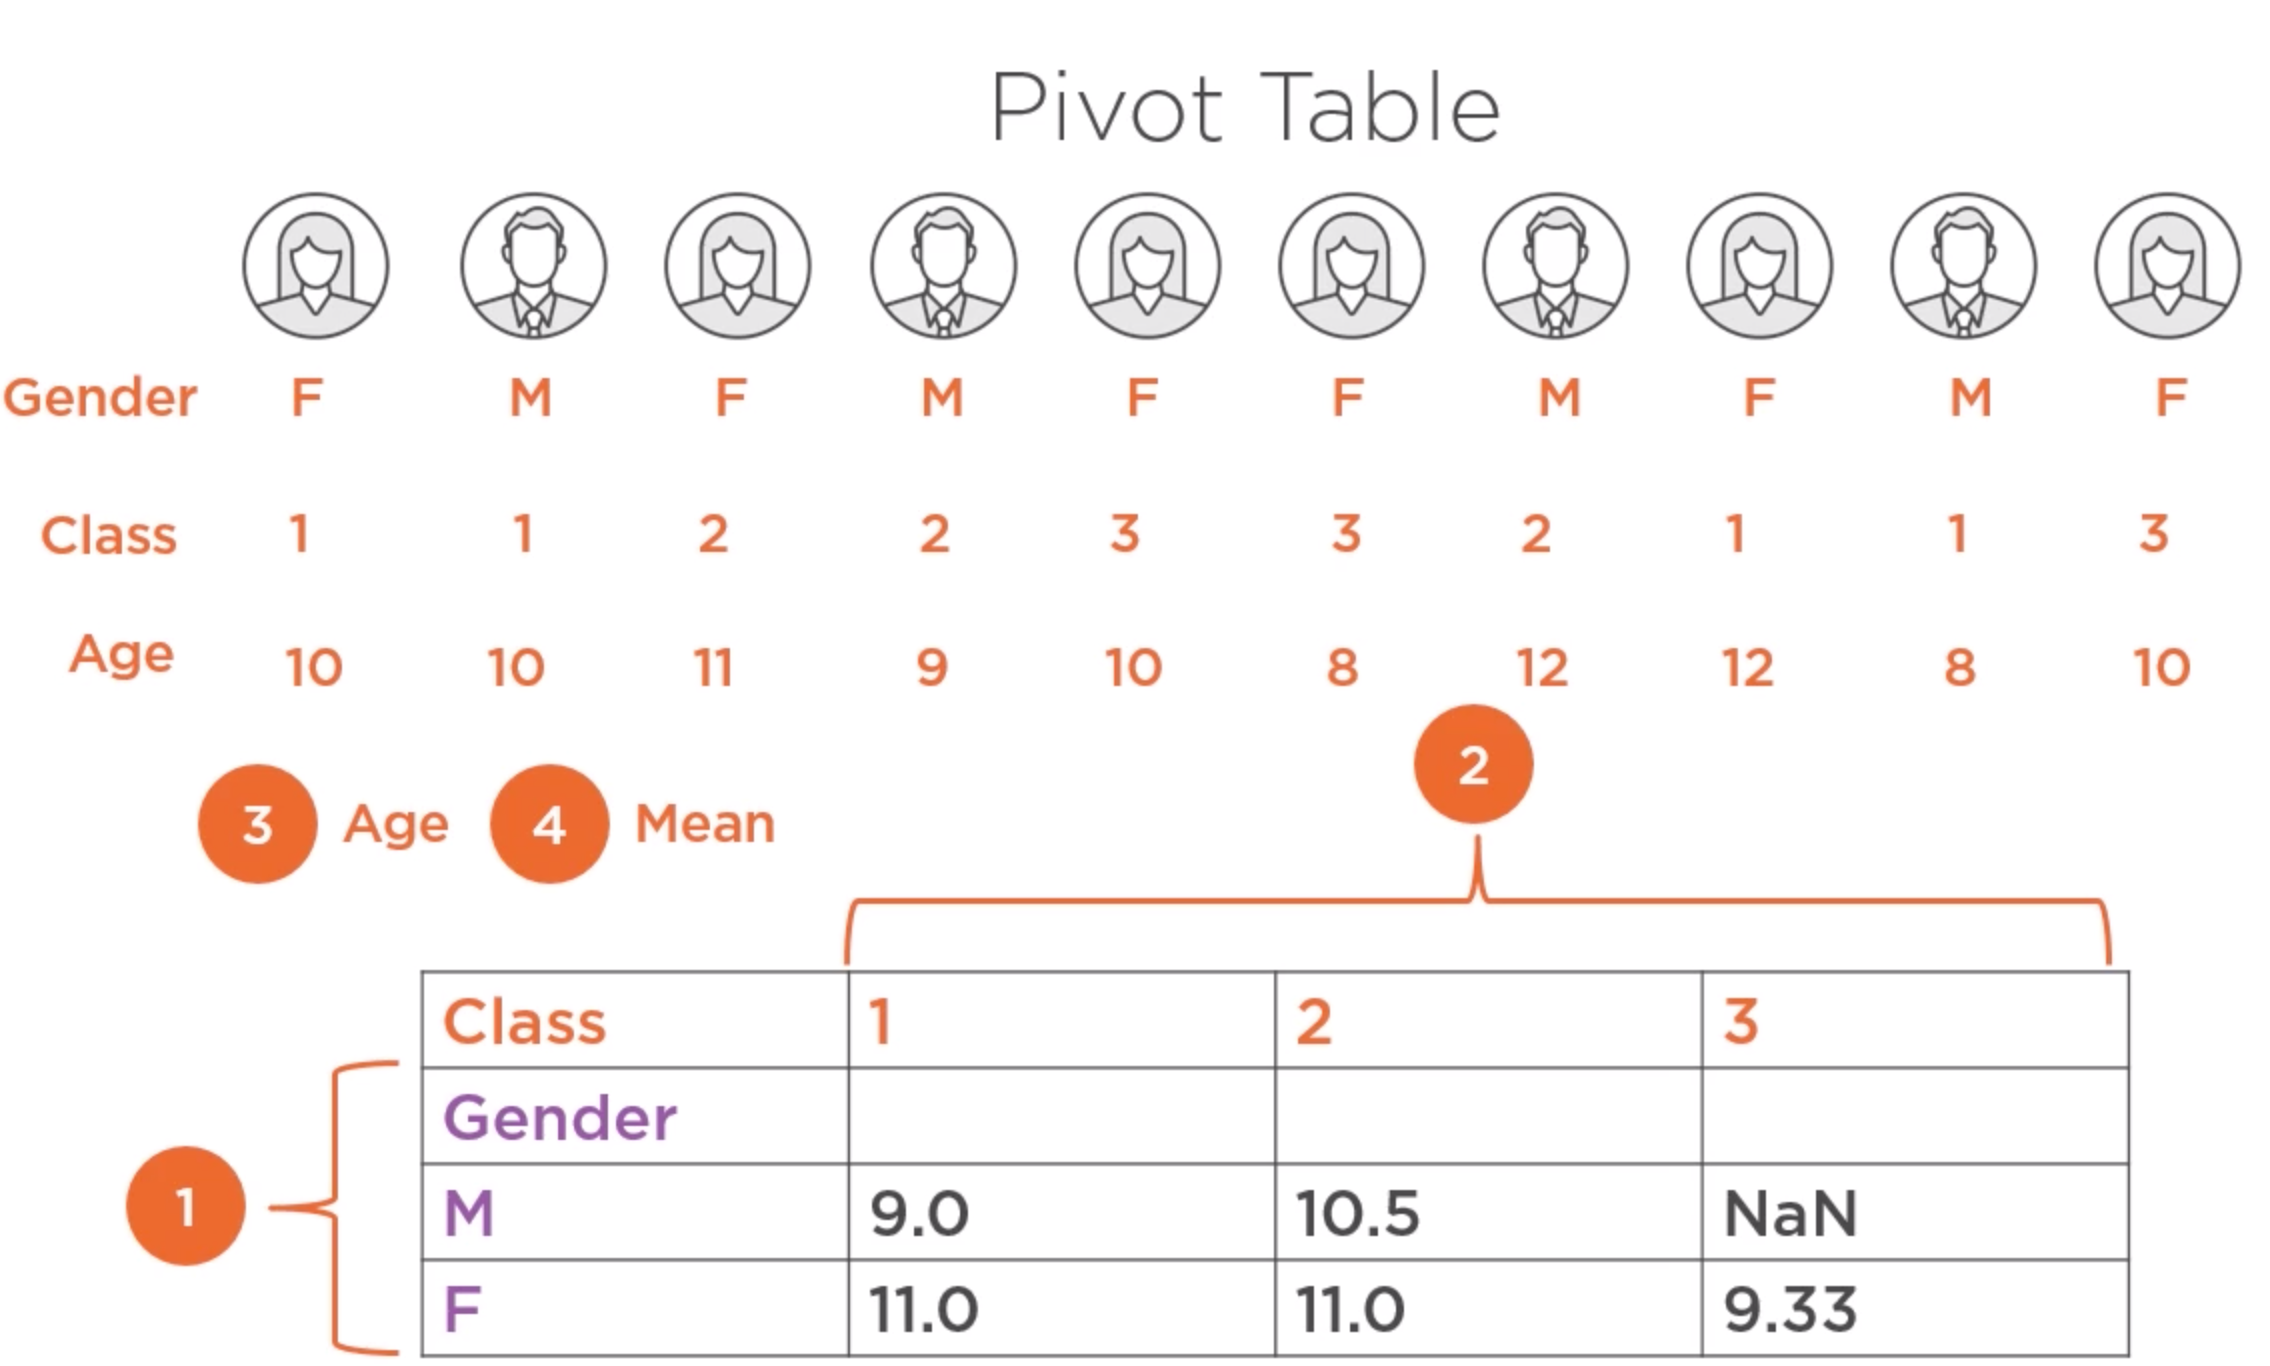

In [72]:
# Equivalente de pivot_table en Polars
pivot_pl = tips_pl.pivot(
    index="time",
    on="smoker",
    values="tip",
    aggregate_function="mean"
)

display(pivot_pl)

time,No,Yes
cat,f64,f64
"""Dinner""",3.126887,3.066
"""Lunch""",2.673778,2.834348


In [73]:
# Equivalente de groupby con múltiples columnas en Polars
grouped_pl = tips_pl.group_by(["time", "smoker"]).agg(
    pl.col("tip").mean()
)

display(grouped_pl)

time,smoker,tip
cat,cat,f64
"""Lunch""","""Yes""",2.834348
"""Dinner""","""Yes""",3.066
"""Lunch""","""No""",2.673778
"""Dinner""","""No""",3.126887


In [74]:
(
grouped_pl.plot.bar(
        x="time",
        y="tip",
        color="smoker"
    )
    .properties(
        title="Propina promedipo - Cena vs Almuerzo",
        width=400
    )
)

alt.Chart(...)

# Fuentes de Datos

__[Data Science for Social Good: Best Sources for Free Open Data](https://towardsdatascience.com/data-science-for-social-good-best-sources-for-free-open-data-5120070caf02)__